# 📊 Students Performance Analysis

---

**Course:** Data Analysis  
**Dataset:** Students Performance in Exams  
**Source:** [Kaggle Dataset](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)  
**Year:** 2025  

---

## 🎯 Project Overview

This project analyzes the academic performance of 1,000 students across math, reading, and writing scores.  
The analysis covers data loading, cleaning, descriptive statistics, visualization, statistical tests, and simulation.

## 📁 Project Structure

| Folder | Description |
|--------|-------------|
| `data/` | Raw dataset |
| `notebooks/` | Analysis notebooks |

## 📌 Sections

1. Data Loading & Exploration  
2. Data Cleaning & Preparation  
3. Descriptive Statistics  
4. Data Visualization  
5. Categorical Data Analysis  
6. Statistical Tests  
7. Statistical Distributions & Simulation

## Section 1 — Data Loading & Exploration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, ttest_rel, chi2_contingency, f_oneway
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

### 1.1 Load Dataset

In [3]:
df = pd.read_csv('../data/StudentsPerformance.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 1.2 Initial Exploration

In [4]:
# Column info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
# Descriptive statistics
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
# Missing values
print("Missing values:")
print(df.isna().sum())

# Duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0


## Section 2 — Data Cleaning & Preparation

### 2.1 Remove Outliers from Math Score (IQR Method)

In [7]:
Q1 = df['math score'].quantile(0.25)
Q3 = df['math score'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['math score'] >= lower) & (df['math score'] <= upper)]

print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")
print(f"Dataset shape after removing outliers: {df.shape}")

Lower bound: 27.0
Upper bound: 107.0
Dataset shape after removing outliers: (992, 8)


### 2.2 Filter Students with Math Score Above 70

In [10]:
df_high = df[df['math score'] > 70].copy()
print(f"Students with math score above 70: {df_high.shape[0]}")
df_high.head()

Students with math score above 70: 391


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group B,master's degree,standard,none,90,95,93
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92


### 2.3 Standardize Math Score

In [12]:
scaler = StandardScaler()
df['math score scaled'] = scaler.fit_transform(df[['math score']])
df[['math score', 'math score scaled']].head()

,math score,math score scaled
0,72,0.379254
1,69,0.173106
2,90,1.616141
3,47,-1.338645
4,76,0.654118


### 2.4 Create Average Score Column

In [13]:
df['average score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
print("Average score column created!")
df[['math score', 'reading score', 'writing score', 'average score']].head()

Average score column created!


,math score,reading score,writing score,average score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


### 2.5 Create Math Level Column

In [14]:
def math_level(score):
    if score >= 80:
        return 'High'
    elif score >= 50:
        return 'Medium'
    else:
        return 'Low'

df['math level'] = df['math score'].map(math_level)
print(df['math level'].value_counts())
df[['math score', 'math level']].head(10)

math level
Medium    672
High      193
Low       127
Name: count, dtype: int64


,math score,math level
0,72,Medium
1,69,Medium
2,90,High
3,47,Low
4,76,Medium
5,71,Medium
6,88,High
7,40,Low
8,64,Medium
9,38,Low


## Section 3 — Descriptive Statistics

### 3.1 Central Tendency & Dispersion of Math Score

In [15]:
print(f"Mean:              {df['math score'].mean():.2f}")
print(f"Median:            {df['math score'].median():.2f}")
print(f"Mode:              {df['math score'].mode()[0]:.2f}")
print(f"Variance:          {df['math score'].var():.2f}")
print(f"Std Deviation:     {df['math score'].std():.2f}")

Mean:              66.48
Median:            66.00
Mode:              65.00
Variance:          211.99
Std Deviation:     14.56


### 3.2 Skewness & Kurtosis

In [16]:
print(f"Skewness:  {df['math score'].skew():.4f}")
print(f"Kurtosis:  {df['math score'].kurt():.4f}")

Skewness:  -0.0693
Kurtosis:  -0.3243


### 3.3 Pearson & Spearman Correlation

In [18]:
pearson_corr = df['math score'].corr(df['reading score'], method='pearson')
spearman_corr = df['math score'].corr(df['reading score'], method='spearman')

print(f"Pearson Correlation:   {pearson_corr:.4f}")
print(f"Spearman Correlation:  {spearman_corr:.4f}")

Pearson Correlation:   0.8068
Spearman Correlation:  0.7994


### 3.4 Simple Linear Regression — Predicting Writing Score from Reading Score

In [19]:
X = df[['reading score']]
y = df['writing score']

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)

print(f"R²:           {r_squared:.4f}")
print(f"Intercept:    {model.intercept_:.4f}")
print(f"Coefficient:  {model.coef_[0]:.4f}")

R²:           0.9073
Intercept:    -0.3077
Coefficient:  0.9888


## Section 4 - Data Visualization

### 4.1 Average Score by parental level of Edcucation (Line plot)

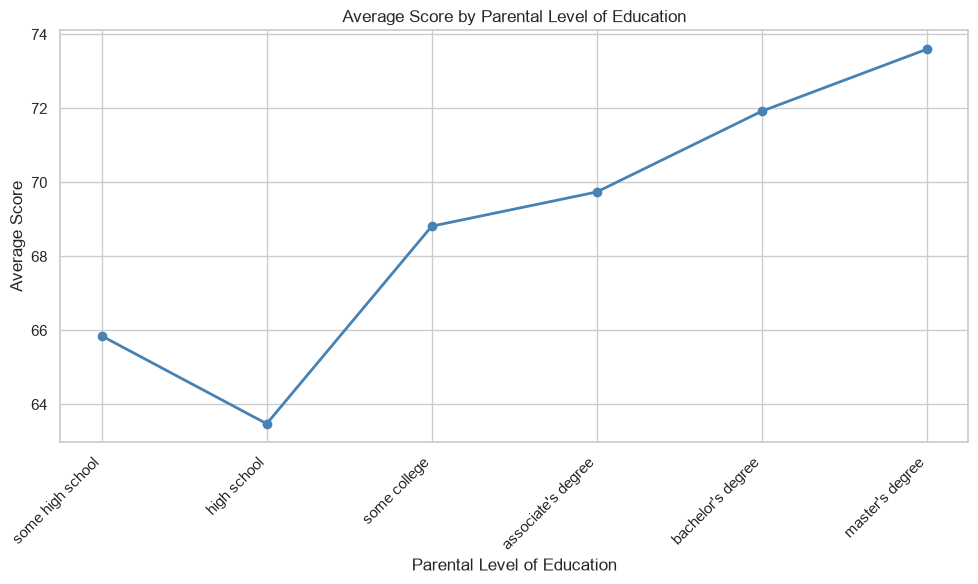

In [20]:
edu_order = ['some high school', 'high school', 'some college', 
             'associate\'s degree', 'bachelor\'s degree', 'master\'s degree']

avg_by_edu = df.groupby('parental level of education')['average score'].mean().reindex(edu_order)

plt.figure(figsize=(10, 6))
plt.plot(avg_by_edu.index, avg_by_edu.values, marker='o', linewidth=2, color='steelblue')
plt.title('Average Score by Parental Level of Education')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.2 Average Math Score by Gender (Bar Plot)

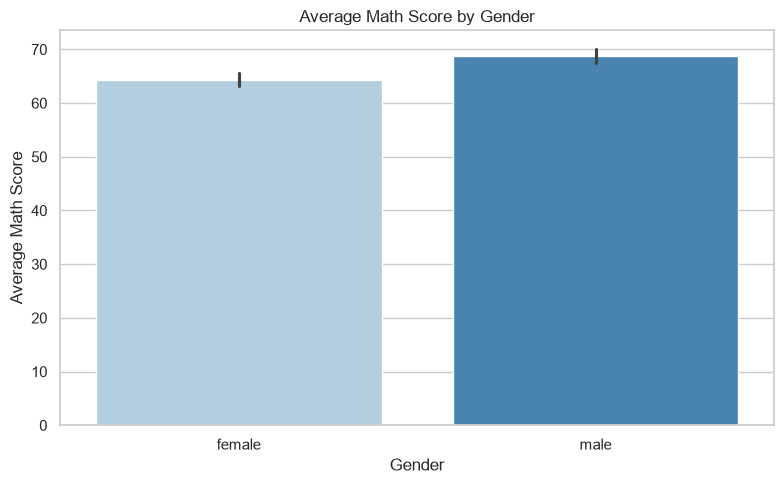

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='gender', y='math score', estimator='mean', palette='Blues')
plt.title('Average Math Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Math Score')
plt.tight_layout()
plt.show()

### 4.3 Parental Level of Education Distribution (Pie Chart)

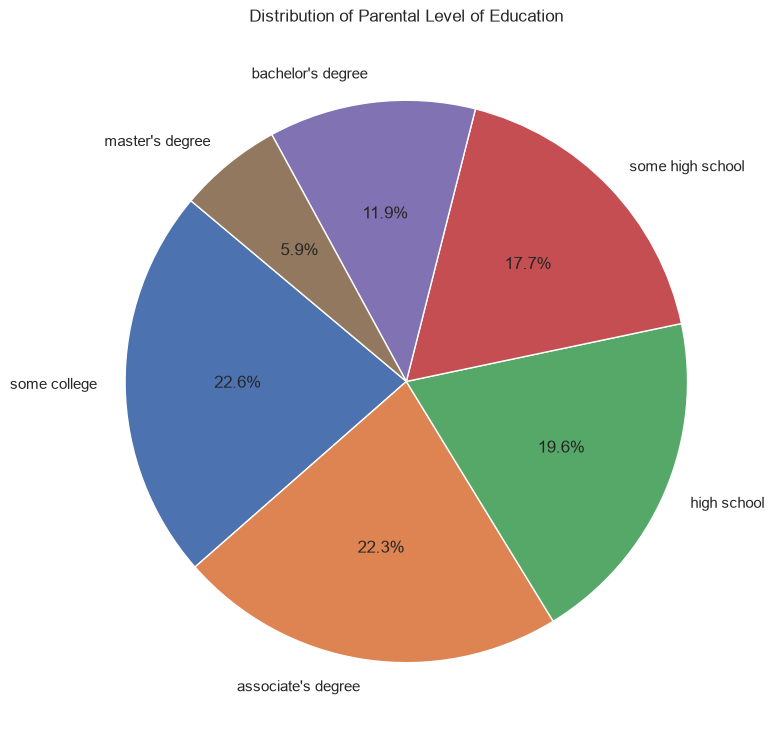

In [24]:
edu_counts = df['parental level of education'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(edu_counts, labels=edu_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Parental Level of Education')
plt.tight_layout()
plt.show()

### 4.4 Math Score Histogram & Average Score Box Plot by Gebder

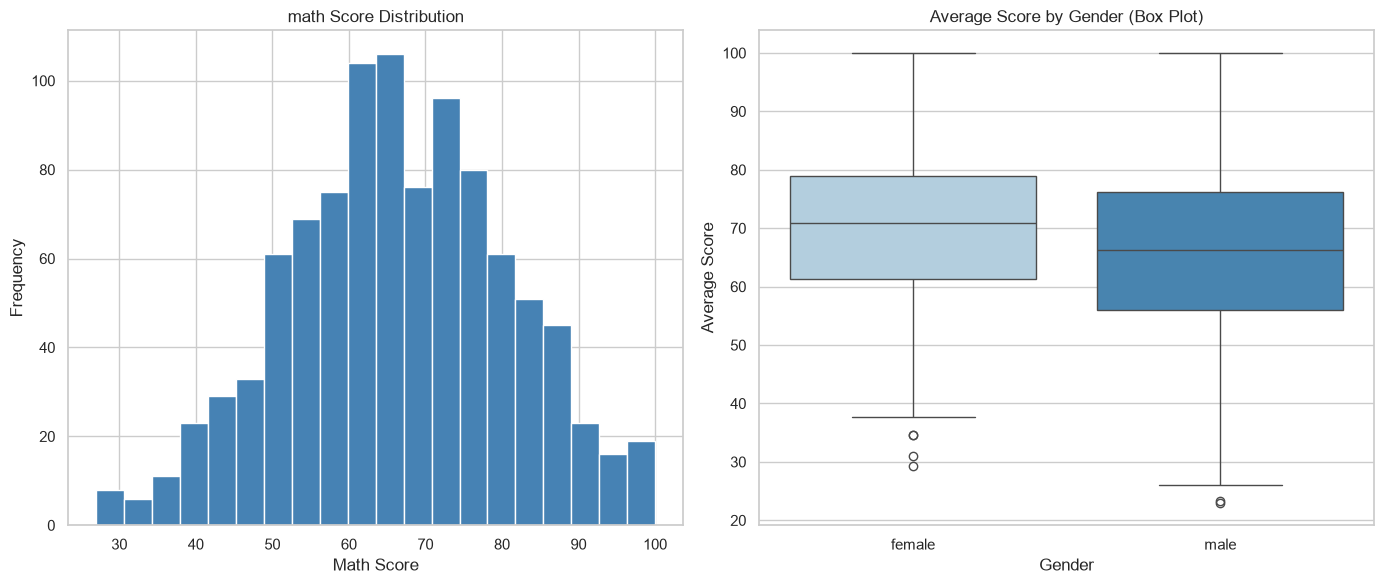

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Histogram
axes[0].hist(df['math score'], bins=20, color='steelblue',edgecolor='white')
axes[0].set_title('math Score Distribution')
axes[0].set_xlabel("Math Score")
axes[0].set_ylabel('Frequency')

# Box Plot
sns.boxplot(data=df, x='gender', y='average score', palette="Blues",ax=axes[1])
axes[1].set_title('Average Score by Gender (Box Plot)')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Average Score')

plt.tight_layout()
plt.show()

### 4.5 Scatter Plot & Correlation heatmap

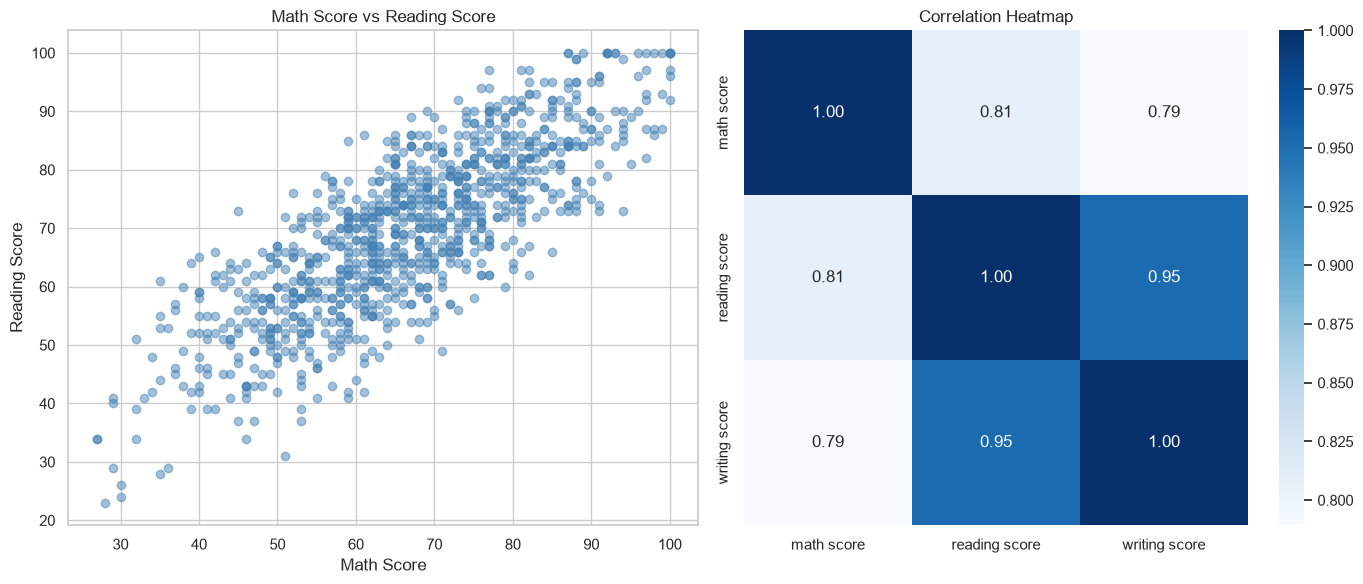

In [26]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

# Scatter Plot
axes[0].scatter(df['math score'], df['reading score'], alpha=0.5, color='steelblue')
axes[0].set_title('Math Score vs Reading Score')
axes[0].set_xlabel('Math Score')
axes[0].set_ylabel('Reading Score')

# Heatmap
corr = df[['math score','reading score','writing score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()